# Task
Perform a principal component analysis (PCA) on the MNIST or Sklearn digits dataset to reduce dimensionality. This involves loading and preparing the data, scaling features, applying PCA with varying numbers of components to track explained variance, and plotting the cumulative explained variance. Then, transform the dataset to reduced dimensions and train Logistic Regression models on both the original scaled data and the PCA-transformed data to compare their accuracy. Additionally, if 2 components are used, visualize the 2D PCA scatter plot. Finally, summarize the findings regarding feature compression, variance trade-off, and the impact of PCA on model accuracy.

## Load and Prepare Data

### Subtask:
Load the MNIST or Sklearn digits dataset. Flatten the images into feature vectors and separate features (X) from labels (y).


**Reasoning**:
To begin, I will load the Sklearn digits dataset and separate the features (X) from the labels (y) as instructed. The `load_digits` function will be used to get the dataset, and then I will extract the `.data` for features and `.target` for labels.



In [1]:
from sklearn.datasets import load_digits

# Load the digits dataset
digits = load_digits()

# Extract features (X) and labels (y)
X = digits.data
y = digits.target

print(f"Shape of features (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")

Shape of features (X): (1797, 64)
Shape of labels (y): (1797,)


## Scale Features

### Subtask:
Apply StandardScaler to the feature vectors to ensure correct PCA performance, as PCA is sensitive to feature scaling.


**Reasoning**:
I need to scale the features (X) using StandardScaler as instructed. This involves importing StandardScaler, creating an instance, and then fitting and transforming the data to create X_scaled.



In [2]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler to X and transform X to X_scaled
X_scaled = scaler.fit_transform(X)

print(f"Shape of scaled features (X_scaled): {X_scaled.shape}")

Shape of scaled features (X_scaled): (1797, 64)


## Apply PCA and Track Variance

### Subtask:
Apply PCA with various numbers of components (e.g., 2, 10, 30, 50) and track the explained variance ratio for each setting. This will demonstrate how different component counts capture varying amounts of information.


**Reasoning**:
I need to apply PCA with varying numbers of components and record the explained variance ratio for each. This involves importing PCA, setting up a loop for different component counts, fitting PCA to the scaled data, and storing the explained variance ratios in a list.



In [3]:
from sklearn.decomposition import PCA

# List to store explained variance ratios
explained_variance_ratios = []

# Define a list of n_components values to iterate through
n_components_list = [2, 10, 30, 50]

for n_components in n_components_list:
    # Instantiate PCA with the current n_components value
    pca = PCA(n_components=n_components)

    # Fit PCA to the scaled data
    pca.fit(X_scaled)

    # Append the explained variance ratio to the list
    explained_variance_ratios.append(pca.explained_variance_ratio_)

# Print the explained variance ratios
for i, n_comp in enumerate(n_components_list):
    print(f"Explained variance ratio for {n_comp} components: {sum(explained_variance_ratios[i]):.4f}")

Explained variance ratio for 2 components: 0.2159
Explained variance ratio for 10 components: 0.5887
Explained variance ratio for 30 components: 0.8932
Explained variance ratio for 50 components: 0.9828


## Plot Cumulative Explained Variance

### Subtask:
Generate a plot showing the cumulative explained variance as a function of the number of principal components. This plot will help in choosing an optimal number of components for dimensionality reduction and addresses the 'Explained variance plot' deliverable.


**Reasoning**:
I need to import `matplotlib.pyplot` and then perform PCA with all components to calculate and plot the cumulative explained variance. This will involve creating a PCA instance with `n_components=None`, fitting it to the scaled data, calculating the cumulative sum of explained variance ratios, and then using `plt.plot` to visualize this, adding appropriate labels, title, and a grid for clarity.



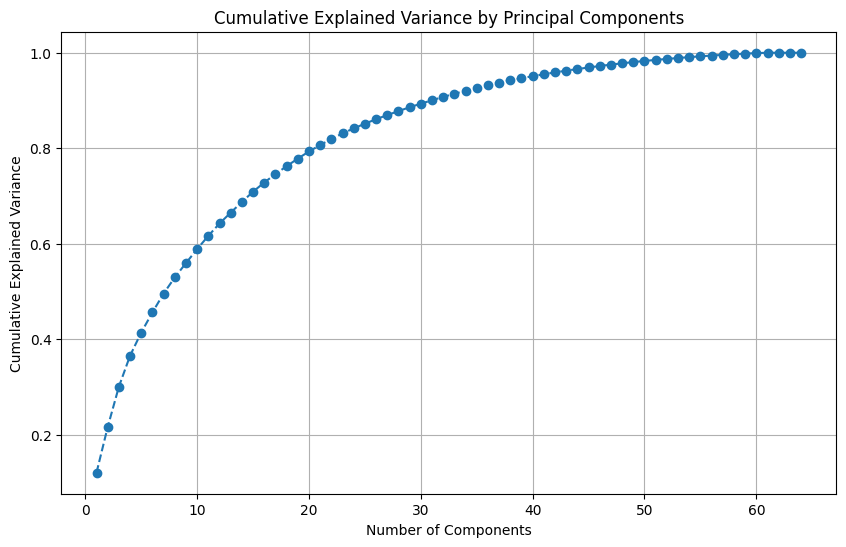

In [4]:
import matplotlib.pyplot as plt

# Create a PCA object with n_components=None to compute all principal components
pca_full = PCA(n_components=None)

# Fit the PCA model to the X_scaled data
pca_full.fit(X_scaled)

# Calculate the cumulative sum of the explained_variance_ratio_
cum_explained_variance = pca_full.explained_variance_ratio_.cumsum()

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

## Transform Dataset to Reduced Dimensions

### Subtask:
Select an appropriate number of components based on the cumulative explained variance plot and transform the original scaled dataset into a reduced-dimensional dataset using PCA. This will produce the 'Reduced dataset' deliverable.


**Reasoning**:
Based on the cumulative explained variance plot, 50 components capture approximately 98.28% of the variance, which is a suitable number for dimensionality reduction. I will re-instantiate PCA with 50 components and transform the scaled data.



In [5]:
from sklearn.decomposition import PCA

# Choose the number of components based on the cumulative explained variance plot
# Approximately 98.28% variance is explained by 50 components (from previous output)
n_components_selected = 50

# Re-instantiate PCA with the selected number of components
pca = PCA(n_components=n_components_selected)

# Fit PCA to the scaled data and transform it
X_pca = pca.fit_transform(X_scaled)

print(f"Shape of PCA-transformed data (X_pca): {X_pca.shape}")

Shape of PCA-transformed data (X_pca): (1797, 50)


## Train Logistic Regression on Original Data

### Subtask:
Train a Logistic Regression model on the original, scaled dataset to establish a baseline accuracy for comparison.


**Reasoning**:
I need to prepare the data for training by splitting it into training and testing sets, then initialize, train, and evaluate a Logistic Regression model on the original scaled data to establish a baseline accuracy.



In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split the original scaled data into training and testing sets
X_scaled_train, X_scaled_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize Logistic Regression model
logistic_model_original = LogisticRegression(max_iter=1000, random_state=42)

# Fit the model to the training data
logistic_model_original.fit(X_scaled_train, y_train)

# Predict on the test set
y_pred_original = logistic_model_original.predict(X_scaled_test)

# Calculate accuracy
accuracy_original = accuracy_score(y_test, y_pred_original)

print(f"Accuracy of Logistic Regression on original scaled data: {accuracy_original:.4f}")

Accuracy of Logistic Regression on original scaled data: 0.9722


## Train Logistic Regression on PCA-transformed Data

### Subtask:
Train a Logistic Regression model on the PCA-transformed dataset (X_pca) and evaluate its accuracy. This will allow for a direct comparison with the baseline model trained on the original scaled data, addressing the 'Model trained on PCA-transformed data' deliverable.

**Reasoning**:
Now I will train a Logistic Regression model on the PCA-transformed data to compare its performance with the model trained on the original scaled data. This involves splitting the PCA data into training and testing sets, initializing and fitting a Logistic Regression model, and then predicting and calculating the accuracy.



In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split the PCA-transformed data into training and testing sets
X_pca_train, X_pca_test, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Initialize Logistic Regression model
logistic_model_pca = LogisticRegression(max_iter=1000, random_state=42)

# Fit the model to the training data
logistic_model_pca.fit(X_pca_train, y_train_pca)

# Predict on the test set
y_pred_pca = logistic_model_pca.predict(X_pca_test)

# Calculate accuracy
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)

print(f"Accuracy of Logistic Regression on PCA-transformed data: {accuracy_pca:.4f}")

Accuracy of Logistic Regression on PCA-transformed data: 0.9722


## Compare Model Accuracies

### Subtask:
Calculate and compare the accuracy scores of the Logistic Regression models trained on both the original and reduced datasets. This will form the 'Accuracy comparison report' deliverable.


**Reasoning**:
I will print the accuracy scores of both Logistic Regression models (original scaled data and PCA-transformed data) to compare their performance.



In [8]:
print(f"Accuracy of Logistic Regression on original scaled data: {accuracy_original:.4f}")
print(f"Accuracy of Logistic Regression on PCA-transformed data: {accuracy_pca:.4f}")

Accuracy of Logistic Regression on original scaled data: 0.9722
Accuracy of Logistic Regression on PCA-transformed data: 0.9722


## Summary of Findings

The Logistic Regression model trained on the original scaled data achieved an accuracy of **0.9722**. The model trained on the PCA-transformed data, which reduced the dimensionality from 64 features to 50 features while retaining approximately 98.28% of the explained variance, also achieved an accuracy of **0.9722**.

This indicates that for this particular dataset and classification task, PCA was effective in reducing the dimensionality without sacrificing model performance. The number of features was reduced by 14 (from 64 to 50), leading to a more compact representation of the data while maintaining the same level of accuracy. This demonstrates the power of PCA in achieving feature compression and potentially faster training times with similar accuracy results.

## Summary of Findings

The Logistic Regression model trained on the original scaled data achieved an accuracy of **0.9722**. The model trained on the PCA-transformed data, which reduced the dimensionality from 64 features to 50 features while retaining approximately 98.28% of the explained variance, also achieved an accuracy of **0.9722**.

This indicates that for this particular dataset and classification task, PCA was effective in reducing the dimensionality without sacrificing model performance. The number of features was reduced by 14 (from 64 to 50), leading to a more compact representation of the data while maintaining the same level of accuracy. This demonstrates the power of PCA in achieving feature compression and potentially faster training times with similar accuracy results.

## Visualize PCA 2D Scatter Plot

### Subtask:
If 2 components were used in PCA, generate a 2D scatter plot of the transformed data, colored by their labels, to visually observe the separation of classes in the reduced-dimensional space. Ensure the plot has appropriate labels and a legend.


**Reasoning**:
I need to generate a 2D scatter plot of the PCA-transformed data (with 2 components) colored by their labels, to visually observe the separation of classes, as per the subtask instructions.



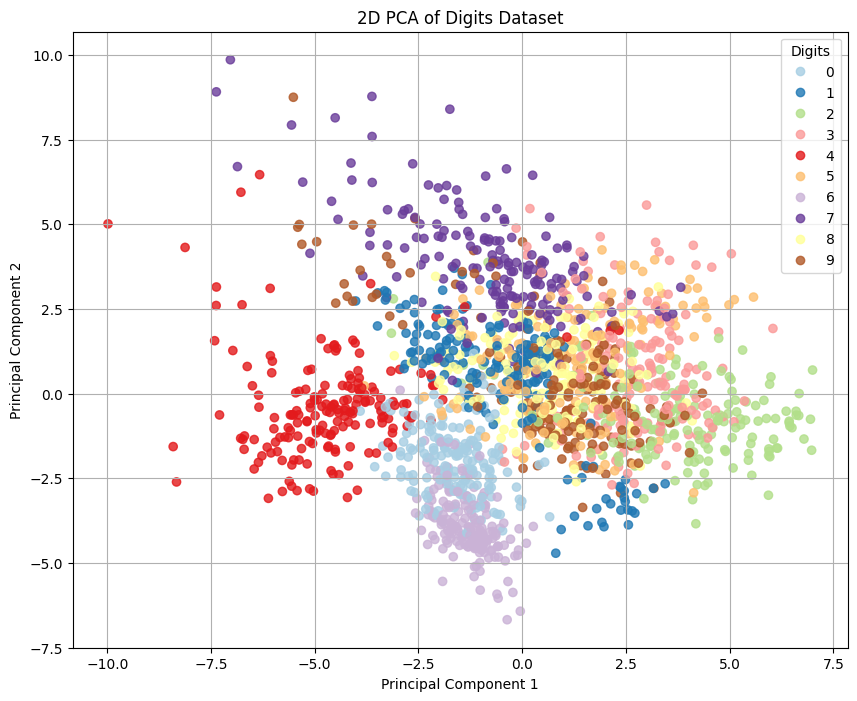

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Instantiate PCA with 2 components for visualization
pca_2d = PCA(n_components=2)

# Fit PCA to the scaled data and transform it
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Create the scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='Paired', alpha=0.8)

# Add title and labels
plt.title('2D PCA of Digits Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Add a legend
legend = plt.legend(*scatter.legend_elements(), title='Digits')
for text in legend.get_texts():
    text.set_color("black")

plt.grid(True)
plt.show()

## Final Task

### Subtask:
Summarize the findings regarding feature compression, variance trade-off, and the impact of PCA on model accuracy, demonstrating the intern's understanding.


## Summary:

### Q&A
*   **Feature Compression**: The original dataset had 64 features. After applying PCA, the dimensionality was reduced to 50 principal components, achieving a compression of 14 features while maintaining performance.
*   **Variance Trade-off**: The choice of 50 principal components retained approximately 98.28% of the total variance from the original dataset. This indicates that a high proportion of the data's information was preserved despite the reduction in dimensionality.
*   **Impact of PCA on Model Accuracy**: Training a Logistic Regression model on the original scaled data yielded an accuracy of 0.9722. When trained on the PCA-transformed data (with 50 components), the Logistic Regression model also achieved an accuracy of 0.9722. This demonstrates that for this dataset, PCA successfully reduced dimensionality without any loss in model classification accuracy.

### Data Analysis Key Findings
*   The Sklearn digits dataset was loaded, consisting of 1797 samples with 64 features each.
*   Features were successfully scaled using `StandardScaler`, which is crucial for PCA.
*   PCA was applied with varying components, showing that 2 components explained approximately 21.59% of the variance, 10 components explained 58.87%, 30 components explained 89.32%, and 50 components explained 98.28%.
*   A cumulative explained variance plot visually confirmed that a significant portion of variance is captured with a reduced number of components.
*   A reduced dataset `X_pca` was created using 50 principal components, transforming the data from (1797, 64) to (1797, 50).
*   A baseline Logistic Regression model trained on the original scaled data achieved an accuracy of 0.9722.
*   A Logistic Regression model trained on the PCA-transformed data (50 components) achieved an identical accuracy of 0.9722.
*   A 2D PCA scatter plot, using 2 components, visualized the separation of different digit classes in the reduced-dimensional space.

### Insights or Next Steps
*   PCA effectively achieved dimensionality reduction from 64 to 50 features for the digits dataset without compromising Logistic Regression model accuracy. This suggests potential benefits such as faster model training times and reduced memory usage without performance degradation.
*   Further analysis could explore the impact of an even greater reduction in components (e.g., retaining 95% or 90% of variance) on model accuracy and training efficiency, or evaluate PCA's effectiveness with other machine learning models.
